In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

In [3]:
df = pd.read_csv('customer_support_tickets.csv')
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [21]:
filtered_df = df.filter(['Ticket Type', 'Ticket Subject', 'Ticket Description'])
filtered_df = filtered_df.rename(columns={'Ticket Type': 'label', 'Ticket Description': 'ticket_text', 'Ticket Subject':'ticket_sub'})
filtered_df.head()

,label,ticket_sub,ticket_text
0,Technical issue,Product setup,I'm having an issue with the {product_purchase...
1,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...
2,Technical issue,Network problem,I'm facing a problem with my {product_purchase...
3,Billing inquiry,Account access,I'm having an issue with the {product_purchase...
4,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...


In [22]:
import re

def clean(text):
  if not isinstance(text, str):
    return ""
  
  text = text.lower()
  text = re.sub(r'\{.*?\}', '', text)
  text = re.sub(r'\n', ' ', text)
  text = re.sub(r'[^a-z\s]', '', text)
  text = re.sub(r'\s+', ' ', text).strip()

  return text

filtered_df['text'] = filtered_df['ticket_sub'].fillna('') + " " + filtered_df["ticket_text"]
filtered_df['text'] = filtered_df['text'].apply(clean)
filtered_df.head()

,label,ticket_sub,ticket_text,text
0,Technical issue,Product setup,I'm having an issue with the {product_purchase...,product setup im having an issue with the plea...
1,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,peripheral compatibility im having an issue wi...
2,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,network problem im facing a problem with my th...
3,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,account access im having an issue with the ple...
4,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,data loss im having an issue with the please a...


In [31]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

def remove_stopwords(text):
  stop_words = stopwords.words('english')

  imp_words = []

  for word in str(text).split():
    word = word.lower()

    if word not in stop_words:
      imp_words.append(word)

  output = " ".join(imp_words)

  return output

filtered_df['text'] = filtered_df['text'].apply(lambda text: remove_stopwords(text))
filtered_df.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/bernardomoraes/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,label,ticket_sub,ticket_text,text
0,Technical issue,Product setup,I'm having an issue with the {product_purchase...,product setup im issue please assist billing z...
1,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,peripheral compatibility im issue please assis...
2,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,network problem im facing problem turning work...
3,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,account access im issue please assist problem ...
4,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,data loss im issue please assist note seller r...


In [32]:
filtered_df.value_counts('label')

label
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [33]:
refund = filtered_df[filtered_df['label'] == 'Refund request']
technical = filtered_df[filtered_df['label'] == 'Technical issue']
cancellation = filtered_df[filtered_df['label'] == 'Cancellation request']
product = filtered_df[filtered_df['label'] == 'Product inquiry']
billing = filtered_df[filtered_df['label'] == 'Billing inquiry']

balanced_refund = refund.sample(n=len(billing), random_state=42)
balanced_technical = technical.sample(n=len(billing), random_state=42)
balanced_cancellation = cancellation.sample(n=len(billing), random_state=42)
balanced_product = product.sample(n=len(billing), random_state=42)

new_df = pd.concat([balanced_refund, balanced_technical, balanced_cancellation, balanced_product]).reset_index(drop=True)
new_df.value_counts('label')

label
Cancellation request    1634
Product inquiry         1634
Refund request          1634
Technical issue         1634
Name: count, dtype: int64

In [52]:
X_train_NB, X_test_NB, y_train_NB, y_test_NB = train_test_split(
 new_df['text'],
 new_df['label'],
 test_size=0.2,
 random_state=42 
)

Accuracy: 24.31192660550459%


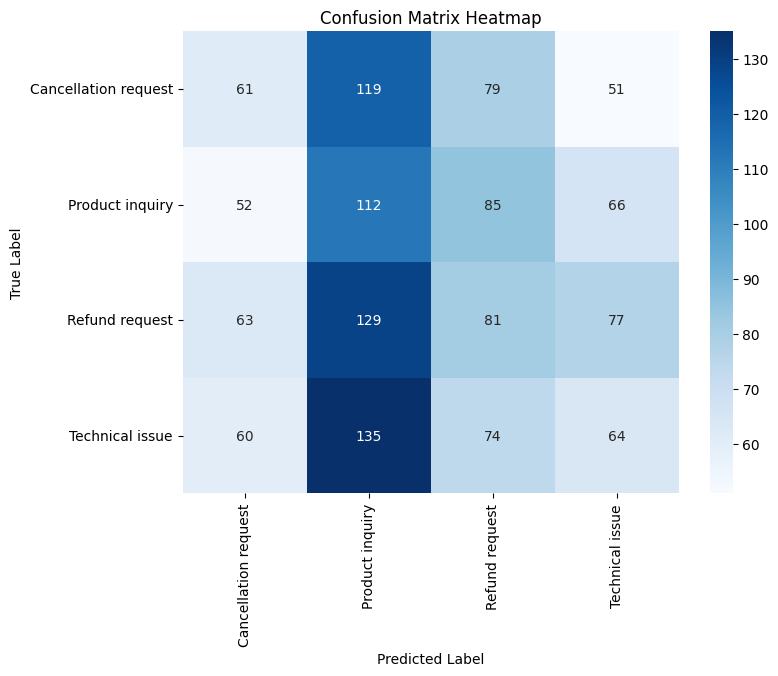

In [44]:
vectorizer = CountVectorizer()
vectorized_X_train = vectorizer.fit_transform(X_train_NB)
vectorized_X_test = vectorizer.transform(X_test_NB)

model = MultinomialNB()
model.fit(vectorized_X_train, y_train_NB)

y_pred = model.predict(vectorized_X_test)

accuracy = accuracy_score(y_test_NB, y_pred)
conf_matrix = confusion_matrix(y_test_NB, y_pred)

print(f'Accuracy: {accuracy*100}%')

class_labels = np.unique(y_test_NB)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



In [54]:
new_df['label_enc'] = new_df['label'].map({'Refund request': 0, 'Technical issue': 1, 'Cancellation request': 2, 'Product inquiry': 3})

X_train_DL, X_test_DL, y_train_DL, y_test_DL = train_test_split(
  new_df['text'],
  new_df['label_enc'],
  test_size=0.2,
  random_state=42
)

X_train_DL_np = X_train_DL.to_numpy()
X_test_DL_np = X_test_DL.to_numpy()
y_train_DL_np = y_train_DL.to_numpy()
y_test_DL_np = y_test_DL.to_numpy()

avg_words_len = round(sum([len(i.split())
                  for i in new_df['text']]) / len(new_df['text']))
total_words_length = len(set(" ".join(new_df['text']).split()))

print(f"Data Loaded. Training samples: {len(X_train_DL_np)}")
print(f"Average words per message: {avg_words_len}")
print(f"Approximate vocabulary size: {total_words_length}")


Data Loaded. Training samples: 5228
Average words per message: 25
Approximate vocabulary size: 5746


In [55]:
from tensorflow.keras.layers import TextVectorization
text_vec = TextVectorization(
  max_tokens = total_words_length,
  standardize = 'lower_and_strip_punctuation',
  output_mode = 'int',
  output_sequence_length = avg_words_len
)

text_vec.adapt(X_train_DL_np)

In [56]:
def compile_and_fit(model,epochs=5):
  model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
  )

  history = model.fit(
    X_train_DL_np,
    y_train_DL_np,
    epochs = epochs,
    validation_data = (X_test_DL_np, y_test_DL_np)
  )

  return history


input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(4, activation='softmax')(x)

model = keras.Model(input_layer, output_layer, name='BiLSTM_model')
history = compile_and_fit(model)

Epoch 1/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.2500 - loss: 1.3871 - val_accuracy: 0.2385 - val_loss: 1.3898
Epoch 2/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.2687 - loss: 1.3844 - val_accuracy: 0.2469 - val_loss: 1.3938
Epoch 3/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.3462 - loss: 1.3420 - val_accuracy: 0.2531 - val_loss: 1.4513
Epoch 4/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.4837 - loss: 1.1671 - val_accuracy: 0.2385 - val_loss: 1.6423
Epoch 5/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.6021 - loss: 0.9439 - val_accuracy: 0.2378 - val_loss: 1.8671


In [58]:
y_preds = model.predict(X_test_DL_np)
y_preds = np.argmax(y_preds, axis=1)
print(accuracy_score(y_test_DL_np, y_preds))

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
0.23776758409785934
